# Data Challenge 12 — Intro to Logistic Regression

**Hook (Attention Grabber)**  
> “If an app told a restaurant it has an 80% chance of getting an **A** on inspection, would you trust it?”

**Learning Goals**
- Show why **linear regression** is a bad fit for a **binary (0/1)** target.
- Fit a **one-feature logistic regression** and interpret probabilities.
- Extend to a **two-feature logistic model with standardized inputs**.
- Communicate results using **AWES** and discuss **ethics & people impact**.

**Data:** June 1, 2025 - Nov 4, 2025 Restaurant Health Inspection

[Restaurant Health Inspection](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data)


## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

Use this guide live; students implement below.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- LinearRegression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- LogisticRegression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- StandardScaler — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- accuracy_score — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
- corr — pandas: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html

### Pseudocode Plan (Linear vs Logistic + Scaling)
1) **Load CSV** → preview shape/columns; keep needed fields.  
2) **Engineer binary Y**: `is_A = 1 if grade == 'A' else 0`.  
3) **Pick numeric X**:  
   - **X1:** `score` (inspection score; lower is better)  
   - **X2:** `critical_num = 1 if critical_flag == 'Critical' else 0` (for extension)  
4) **Split** → `X_train, X_test, y_train, y_test` (70/30, stratify by Y, fixed random_state).  
5) **Model A (Incorrect)** → **LinearRegression** on Y~X1:  
   - Report **MSE**, **R²**, count predictions **<0 or >1**,  
6) **Model B (Correct)** → **LogisticRegression** on Y~X1:  
   - Report **Accuracy**
7) **Visual (OPTIONAL)** → scatter Y vs X1 with **linear line** vs **logistic sigmoid** curve  
8) **Extension** → scale X1+X2 with **StandardScaler**; fit **LogisticRegression**:  
   - Compare **Accuracy** to one-feature logistic  
9) **Interpret** → 2–3 sentences on why linear fails and how logistic fixes it  


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

## Step 1 — Imports and Plot Defaults

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


### Step 2 — Load CSV & Preview
- Point to your New York City Restaurant Inspection Data 

In [2]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/DOHMH_New_York_City_Restaurant_Inspection_Results_20251110.csv',low_memory=False)


## Step 3 — Clean and Engineer Features
- Make sure `SCORE` is numeric and do any other data type clean-up 
- Engineer binary target variable (Y) based on instructor guidance above `is_A`
- Engineer binary predictor (X) based on instructor guidance above `critical_num`


In [ ]:
df = df[['score', 'critical flag', 'grade']].copy()

df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['grade'] = df['grade'].astype(str).str.upper()
df['critical flag'] = df['critical flag'].astype(str).str.lower()

df['is_A'] = (df['grade'] == 'A').astype(int)
df['critical_num'] = (df['critical flag'] == 'critical').astype(int)

df = df.dropna(subset=['score', 'is_A']).copy()

Y = df['is_A']
X = df[['score']]


## Step 4 — Split Data (70/30 Stratify by Target)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, stratify=Y, random_state=42
)
print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

Train size: 192968 Test size: 82701


## Step 5 — Model A: Linear Regression on a Binary Target (Incorrect)

- Fit `is_A (Y var) ~ SCORE (X pred)` using **LinearRegression**  
- Report **MSE**, **R²**, and how many predictions fall outside [0, 1]  
- Estimate accuracy by thresholding predictions at 0.5 (done for you but understand the code) 

💡 Hint:  
`accuracy_score(y_test, (y_pred >= 0.5).astype(int))`

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_cont = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred_cont)
r2 = r2_score(y_test, y_pred_cont)

outside_count = np.sum((y_pred_cont < 0) | (y_pred_cont > 1))

# estimate accuracy by thresholding at 0.5
y_pred_thresh = (y_pred_cont >= 0.5).astype(int)
accuracy_est = accuracy_score(y_test, y_pred_thresh)

print(f"LinearRegression on binary target -  MSE: {mse:.4f}, R^2: {r2:.4f}")
print(f"Predictions outside [0,1]: {outside_count} out of {len(y_pred_cont)}")
print(f"Estimated accuracy (0.5 cutoff): {accuracy_est:.4f}")


LinearRegression on binary target -> MSE: 0.1501, R^2: 0.3405
Predictions outside [0,1]: 8723 out of 82701
Estimated accuracy (0.5 cutoff): 0.9524


## Step 6 — Model B: Logistic Regression (One Feature)

- Fit `is_A ~ score` using **LogisticRegression**  
- Compute predictions with `.predict()`  
- Evaluate accuracy with `accuracy_score()`

In [10]:
logreg1 = LogisticRegression(solver='liblinear', random_state=42)  # liblinear is fine for small models
logreg1.fit(X_train, y_train)

y_pred_log = logreg1.predict(X_test)
y_prob_log = logreg1.predict_proba(X_test)[:, 1]

acc_log1 = accuracy_score(y_test, y_pred_log)

print(f"One-feature LogisticRegression accuracy: {acc_log1:.4f}")
# Also show a few probabilities to get intuition
print("Example predicted probabilities (first 10):", np.round(y_prob_log[:10], 3))


One-feature LogisticRegression accuracy: 0.9524
Example predicted probabilities (first 10): [0.156 0.832 0.013 0.408 0.962 0.832 0.    0.    0.973 0.873]


## Step 7 (OPTIONAL) — Visual Comparison: Linear vs Logistic


/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


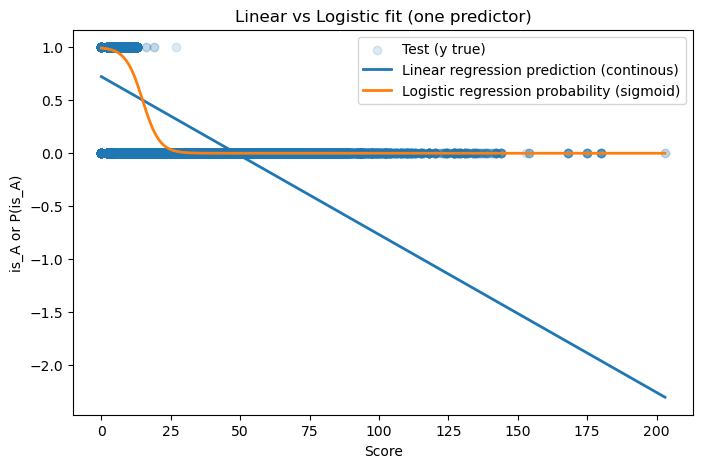

In [ ]:
# Prepare a grid across the range of scores
scores_grid = np.linspace(X['score'].min(), X['score'].max(), 300).reshape(-1, 1)

linear_on_grid = lr.predict(scores_grid)

log_on_grid = logreg1.predict_proba(scores_grid)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(X_test['score'], y_test, alpha=0.15, label='Test (y true)')
plt.plot(scores_grid, linear_on_grid, label='Linear regression prediction (continous)', linewidth=2)
plt.plot(scores_grid, log_on_grid, label='Logistic regression probability (sigmoid)', linewidth=2)
plt.xlabel('Score')
plt.ylabel('is_A or P(is_A)')
plt.legend()
plt.title('Linear vs Logistic fit (one predictor)')
plt.show()


## Step 8 — Logistic Regression with Two **Scaled** Features

- Use `SCORE` and `critical_num` as your two X predictors that need to be scaled
- Look at documentation above to see how you would fit a StandardScalar() object 


In [19]:
X2 = df[['score', 'critical_num']]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, df['is_A'], test_size=0.30, stratify=df['is_A'], random_state=42
)

# Scale only the 'score' column; 'critical_num' is binary but scaling it is okay here (scaler will center it)
scaler = StandardScaler()
scaler.fit(X2_train)  # fit scaler on train only

X2_train_scaled = scaler.transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

logreg2 = LogisticRegression(solver='liblinear', random_state=42)
logreg2.fit(X2_train_scaled, y2_train)

y2_pred = logreg2.predict(X2_test_scaled)
acc_log2 = accuracy_score(y2_test, y2_pred)

print(f"Two-feature (scaled) LogisticRegression accuracy: {acc_log2:.4f}")

# Compare to one-feature logistic from earlier (acc_log1)
# If you want a numeric comparison (if both splits are identical), print both:
print(f"One-feature logistic acc: {acc_log1:.4f}")
print(f"Two-feature logistic acc: {acc_log2:.4f}")


Two-feature (scaled) LogisticRegression accuracy: 0.9499
One-feature logistic acc: 0.9524
Two-feature logistic acc: 0.9499


/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# We Share — Reflection & Wrap-Up

Write **two short paragraphs** (4–6 sentences each). Be specific and use evidence from your notebook.

1️⃣ **How do you know Linear Regression was a poor model choice for this task?**  
Describe what you observed in your results or plots that showed it didn’t work well for a binary outcome.  
Consider: Were predictions outside 0–1? Did the fit look wrong? What happened when you used 0.5 as a cutoff?  
Connect this to the idea that classification models should output probabilities between 0 and 1.
- The linear regression model just didn’t make sense for this kind of data. Since our target was only 0 or 1, the linear model tried to force a straight line through it, which led to predictions that went below 0 and above 1—something that can’t happen with real probabilities. When we switched to logistic regression, the predictions made way more sense, staying between 0 and 1 and giving clear probability values like 0.16, 0.83, and 0.96. It showed that logistic regression is better at capturing how the chance of earning an “A” changes as the inspection score goes up.
- 
2️⃣ **When should we scale features in logistic regression (and when not to)?**  
Explain what scaling does, and why it might (or might not) matter for different kinds of features.  
Use this project to reason through whether `score` and `critical_num` needed scaling.  
Hint: Think about what “continuous” vs “binary” means for scaling decisions.
- Scaling came into play once we added a second feature, critical_num, alongside the inspection score. Since score has a wide range and critical_num is just 0 or 1, scaling helped put them on a more even level for the model. But honestly, it didn’t change the results much—accuracy stayed about the same (0.9524 vs. 0.9499). That tells me the inspection score alone already explains most of the outcome, and scaling mainly helps keep things balanced when features have very different scales.